

---


#**Optimizing Retail Assortment Planning with Machine Learning and Data Analytics**


**Team Members:**
* **Name: Laila abdulrahman** **ID: S2026_214**
* **Name: Lujain Thouqan** **ID: S2026_193**
* **Name: Duaa Abdelbagi** **ID: S2026_175**









## **Online Retail Dataset**

####**Description**

**The Online Retail dataset**, sourced from the UCI Machine Learning Repository, provides a comprehensive look at the transaction history of a UK online retailer between December 1, 2010, and December 9, 2011. This dataset is particularly valuable for this project because it contains over 540,000 observations detailing the sale of unique items to both individual consumers and wholesalers.

**Attribute Significance**

The dataset includes eight key attributes that directly support our assortment optimization goals:

**Identification:** InvoiceNo and StockCode allow us to track unique transactions and individual product movements.

**Product Context:** Description provides the qualitative data needed for category-level analysis.

**Performance Metrics:** Quantity and UnitPrice are essential for calculating total revenue and identifying high-value items.

**Temporal & Geographic Trends:** InvoiceDate and Country enable the team to analyze seasonal demand shifts and regional preferences.

**Application in Project Methodology**

To achieve the project objective of reducing stockouts and overstock, the dataset will be utilized in a three-phased analytical approach:

**Data Preprocessing:** Rigorous cleaning will be conducted to handle missing CustomerID values, remove transaction cancellations (marked with 'C'), and filter out non-product administrative entries to ensure high data integrity.

**Product Categorization:** We will apply ABC Analysis to classify products into tiers based on their revenue contribution, helping prioritize the core assortment.

**Predictive Modeling:** The historical data will be used to train Linear Regression and Random Forest models. These models will forecast future demand trends, providing the data-driven insights required to optimize stock levels and improve overall retail efficiency.**The Online Retail dataset**, sourced from the UCI Machine Learning Repository, provides a comprehensive look at the transaction history of a UK online retailer between December 1, 2010, and December 9, 2011. This dataset is particularly valuable for this project because it contains over 540,000 observations detailing the sale of unique items to both individual consumers and wholesalers.

#####**Dataset Columns Description**

Below are the number of columns, column names, column description, & datatype of each column.

**InvoiceNo:** A unique 6-digit identifier for each transaction. Invoices starting with 'C' denote cancellations and will be removed during preprocessing. Datatype: Character/Nominal

**StockCode:** A unique 5-digit identifier assigned to each distinct product in the inventory. This is the primary key for our ABC Classification. Datatype: Character/Nominal

**Description:** The textual name of the product. This will be used to filter out administrative records like "Postage" or "Bank Charges." Datatype: Character/Nominal

**Quantity:** The number of units per transaction. Negative values indicate returns and will be filtered to reflect true demand. Datatype: Numeric

**InvoiceDate:** The date and time when each transaction was generated. Essential for analyzing seasonal demand trends and time-series forecasting. Datatype: DateTime

**UnitPrice:** The product price per unit in Sterling (£). This is required to calculate the total revenue for our assortment optimization metrics. Datatype: Numeric

**CustomerID:** A unique 5-digit identifier for each customer. Rows with missing IDs will be dropped to ensure data integrity for customer-level analysis. Datatype: Character/Nominal

**Country:** The name of the country where the customer resides. Used for geographic segmentation of product performance. Datatype: Character/NominalBelow are the number of columns, column names, column description, & datatype of each column.

####**Install + Load Libraries**

In [ ]:
install.packages(c("readxl", "dplyr", "ggplot2", "lubridate", "janitor",
                   "tidyr", "stringr", "forcats", "randomForest", "Metrics", "zoo","gbm","xgboost"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


Warning message in install.packages(c("readxl", "dplyr", "ggplot2", "lubridate", :
“installation of package ‘forcats’ had non-zero exit status”


In [ ]:
library(readxl)
library(dplyr)
library(ggplot2)
library(lubridate)
library(janitor)
library(tidyr)
library(stringr)
library(forcats)
library(randomForest)
library(Metrics)
library(zoo)
library(gbm)
library(xgboost)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



####**Load the Dataset**

In [ ]:
df <- read_excel("Online Retail.xlsx")

####**Data Inspection**

#####**Preview First Rows**

In [ ]:
head(df)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


#####**Dataset Structure**

In [ ]:
str(df)

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


#####**Statistical Summary**

In [ ]:
summary(df)

  InvoiceNo          StockCode         Description           Quantity         
 Length:541909      Length:541909      Length:541909      Min.   :-80995.000  
 Class :character   Class :character   Class :character   1st Qu.:     1.000  
 Mode  :character   Mode  :character   Mode  :character   Median :     3.000  
                                                          Mean   :     9.552  
                                                          3rd Qu.:    10.000  
                                                          Max.   : 80995.000  
                                                                              
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:

#####**Unique Values Check**

In [ ]:
cat("Number of unique products:", length(unique(df$Description)), "\n")
cat("Number of unique invoices:", length(unique(df$InvoiceNo)), "\n")
cat("------------------------------------------------")
unique(df$Country)

Number of unique products: 4212 
Number of unique invoices: 25900 
------------------------------------------------

[1] "United Kingdom"       "France"               "Australia"           
 [4] "Netherlands"          "Germany"              "Norway"              
 [7] "EIRE"                 "Switzerland"          "Spain"               
[10] "Poland"               "Portugal"             "Italy"               
[13] "Belgium"              "Lithuania"            "Japan"               
[16] "Iceland"              "Channel Islands"      "Denmark"             
[19] "Cyprus"               "Sweden"               "Austria"             
[22] "Israel"               "Finland"              "Bahrain"             
[25] "Greece"               "Hong Kong"            "Singapore"           
[28] "Lebanon"              "United Arab Emirates" "Saudi Arabia"        
[31] "Czech Republic"       "Canada"               "Unspecified"         
[34] "Brazil"               "USA"                  "European Community"  
[37] "Malta"                "RSA"

#####**Column Names**

In [ ]:
colnames(df)

[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"

#####**Dataset Dimensions**

In [ ]:
dim(df)

[1] 541909      8

#####**Missing Values Count**

In [ ]:
colSums(is.na(df))

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

####**Data Cleaning**

In [ ]:
df_clean <- df

##### **Remove Missing CustomerID**

In [ ]:
df_clean <- df_clean %>%
  filter(!is.na(CustomerID))

##### **Remove Missing Description**

In [ ]:
df_clean <- df_clean %>%
  filter(!is.na(Description))

##### **Verify No Remaining NAs**

In [ ]:
colSums(is.na(df_clean))

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0           0           0           0           0 
 CustomerID     Country 
          0           0

##### **Remove Duplicate Rows**

In [ ]:
df_clean <- df_clean %>%
  distinct()

##### **Remove Non-Positive Quantities**

In [ ]:
df_clean <- df_clean %>%
  filter(Quantity > 0)

##### **Remove Non-Positive Prices**

In [ ]:
df_clean <- df_clean %>%
  filter(UnitPrice > 0)

##### **Remove Cancelled Transactions**

In [ ]:
df_clean <- df_clean %>%
  filter(!str_starts(InvoiceNo, "C"))

#####**Standardize Country Names**

In [ ]:
df_clean <- df_clean %>%
  mutate(
    Country = case_when(
      Country == "EIRE" ~ "Ireland",
      Country == "RSA" ~ "South Africa",
      Country == "USA" ~ "United States",
      Country == "European Community" ~ "Other",
      Country == "Unspecified" ~ "Other",
      TRUE ~ Country
    )
  )

##### **Verify Country Values**

In [ ]:
unique(df_clean$Country)

[1] "United Kingdom"       "France"               "Australia"           
 [4] "Netherlands"          "Germany"              "Norway"              
 [7] "Ireland"              "Switzerland"          "Spain"               
[10] "Poland"               "Portugal"             "Italy"               
[13] "Belgium"              "Lithuania"            "Japan"               
[16] "Iceland"              "Channel Islands"      "Denmark"             
[19] "Cyprus"               "Sweden"               "Finland"             
[22] "Austria"              "Greece"               "Singapore"           
[25] "Lebanon"              "United Arab Emirates" "Israel"              
[28] "Saudi Arabia"         "Czech Republic"       "Canada"              
[31] "Other"                "Brazil"               "United States"       
[34] "Bahrain"              "Malta"                "South Africa"

##### **Cleaning Summary**

In [ ]:
cat("Rows before cleaning:", nrow(df), "\n")
cat("Rows after cleaning:", nrow(df_clean), "\n")

Rows before cleaning: 541909 
Rows after cleaning: 392692 


####**Feature Engineering**

In [ ]:
df_clean <- df_clean %>%
  mutate(
    Revenue = Quantity * UnitPrice,
    Year = year(InvoiceDate),
    Month = month(InvoiceDate, label = TRUE, abbr = FALSE),
    MonthNum = month(InvoiceDate),
    Day = day(InvoiceDate),
    Weekday = wday(InvoiceDate, label = TRUE, abbr = FALSE)
  )

##### **Preview Engineered Features**

In [ ]:
head(df_clean,10)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthNum,Day,Weekday
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<ord>,<dbl>,<int>,<ord>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,December,12,1,Wednesday
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,1,Wednesday
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,December,12,1,Wednesday
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,1,Wednesday
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,1,Wednesday
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010,December,12,1,Wednesday
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010,December,12,1,Wednesday
536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,December,12,1,Wednesday
536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,December,12,1,Wednesday


####**EDA**

#####**Top 10 products by quantity**

In [ ]:
top_products_qty <- df_clean %>%
  group_by(Description) %>%
  summarise(total_quantity = sum(Quantity, na.rm = TRUE)) %>%
  arrange(desc(total_quantity)) %>%
  slice_head(n = 10)

top_products_qty

Description,total_quantity
<chr>,<dbl>
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


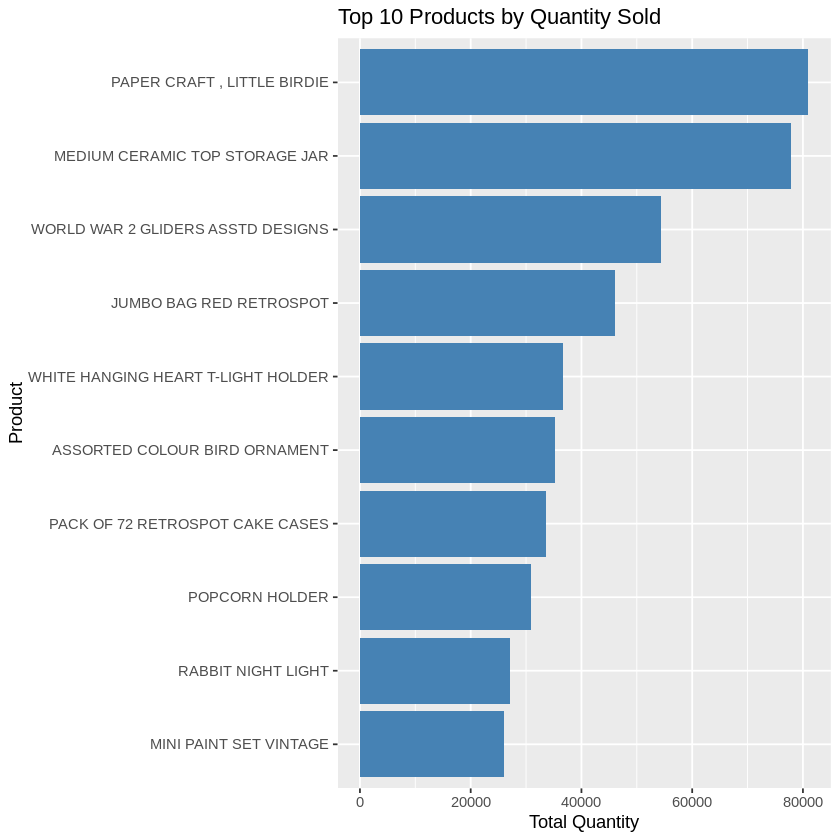

In [ ]:
ggplot(top_products_qty, aes(x = reorder(Description, total_quantity), y = total_quantity)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Products by Quantity Sold",
       x = "Product",
       y = "Total Quantity")

#####**Top 10 products by revenue**

In [ ]:
top_products_rev <- df_clean %>%
  group_by(Description) %>%
  summarise(total_revenue = sum(Revenue, na.rm = TRUE)) %>%
  arrange(desc(total_revenue)) %>%
  slice_head(n = 10)

top_products_rev

Description,total_revenue
<chr>,<dbl>
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


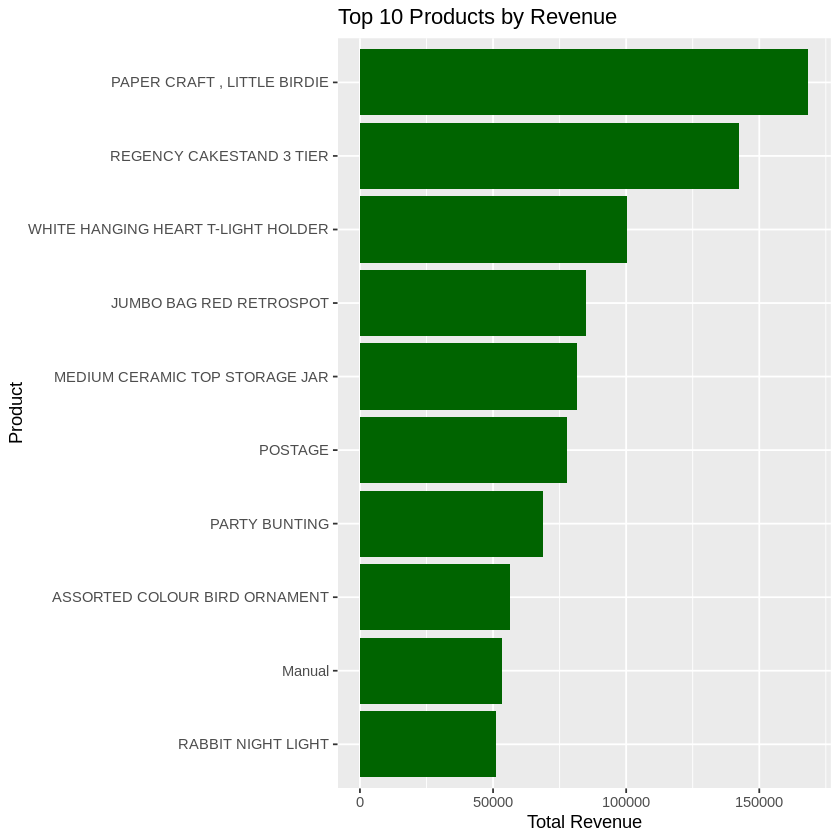

In [ ]:
ggplot(top_products_rev, aes(x = reorder(Description, total_revenue),
                            y = total_revenue)) +
  geom_col(fill = "darkgreen") +
  coord_flip() +
  labs(title = "Top 10 Products by Revenue",
       x = "Product",
       y = "Total Revenue")

#####**Top customers by frequency**

In [ ]:
top_customers <- df_clean %>%
  group_by(CustomerID) %>%
  summarise(
    total_orders = n_distinct(InvoiceNo),
    total_revenue = sum(Revenue, na.rm = TRUE)
  ) %>%
  arrange(desc(total_orders)) %>%
  slice_head(n = 10)

top_customers

CustomerID,total_orders,total_revenue
<dbl>,<int>,<dbl>
12748,209,33053.19
14911,201,143711.17
17841,124,40519.84
13089,97,58762.08
14606,93,12076.15
15311,91,60632.75
12971,86,11189.91
14646,73,280206.02
16029,63,80850.84


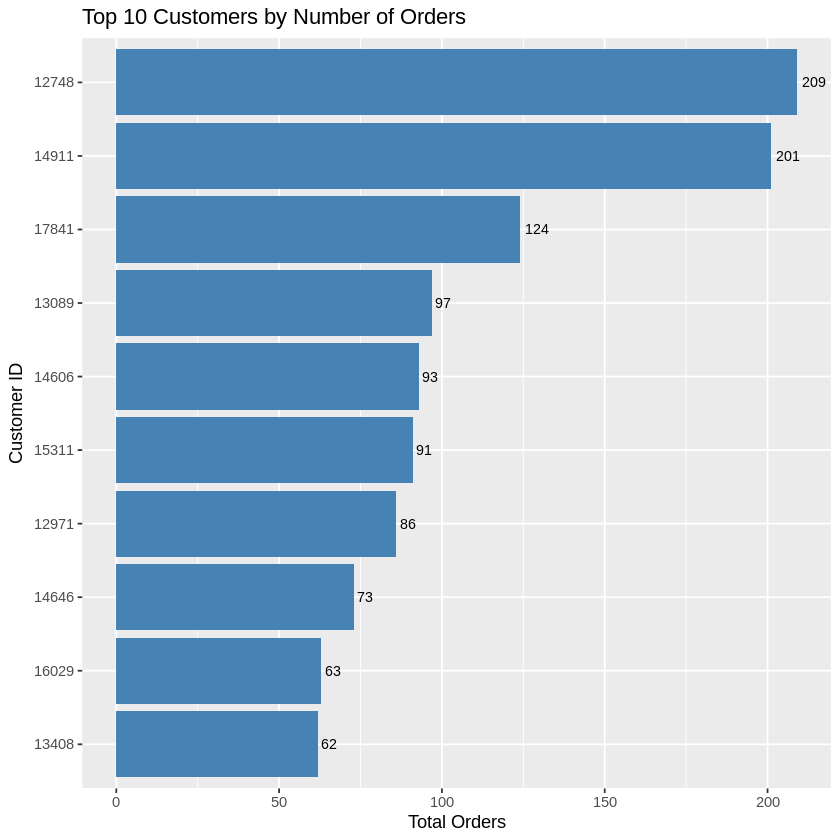

In [ ]:
ggplot(top_customers, aes(x = reorder(as.character(CustomerID), total_orders),
                          y = total_orders)) +
  geom_col(fill = "steelblue") +
  geom_text(aes(label = total_orders), hjust = -0.2, size = 3) +
  coord_flip() +
  labs(title = "Top 10 Customers by Number of Orders",
       x = "Customer ID",
       y = "Total Orders")

#####**Sales by country**

In [ ]:
sales_by_country <- df_clean %>%
  group_by(Country) %>%
  summarise(total_revenue = sum(Revenue, na.rm = TRUE)) %>%
  arrange(desc(total_revenue))

head(sales_by_country, 10)

Country,total_revenue
<chr>,<dbl>
United Kingdom,7285024.64
Netherlands,285446.34
Ireland,265262.46
Germany,228678.40
France,208934.31
Australia,138453.81
Spain,61558.56
Switzerland,56443.95
Belgium,41196.34


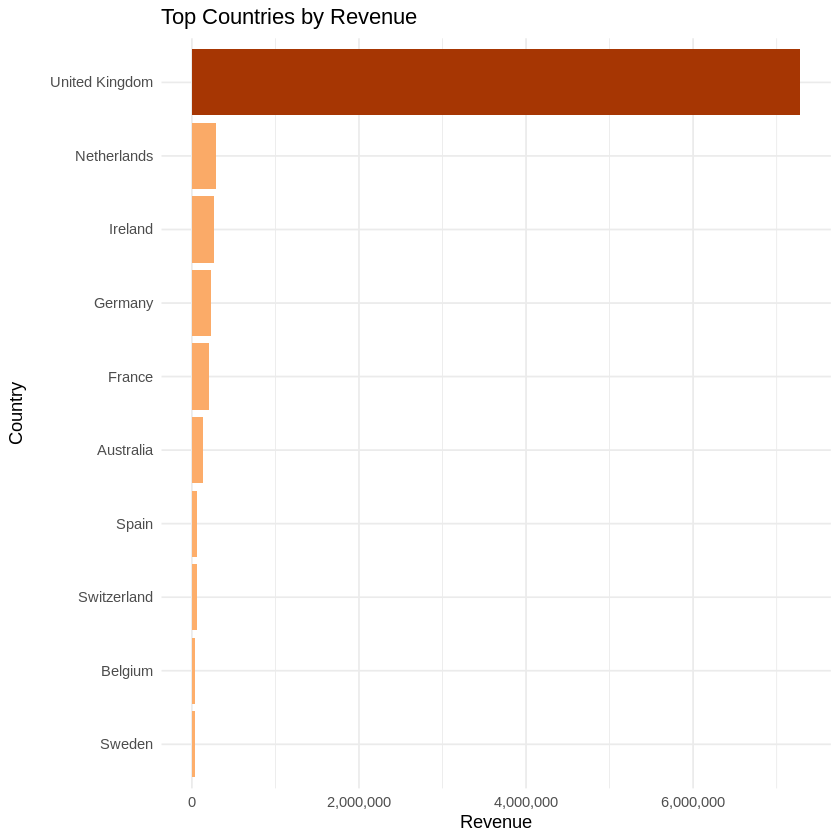

In [ ]:
ggplot(sales_by_country %>%
         arrange(desc(total_revenue)) %>%
         slice_head(n = 10),
       aes(x = reorder(Country, total_revenue),
           y = total_revenue,
           fill = total_revenue)) +
  geom_col() +
  coord_flip() +
  labs(title = "Top Countries by Revenue",
       x = "Country",
       y = "Revenue") +
  scale_fill_gradient(low = "#fdae6b", high = "#a63603") +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal() +
  theme(legend.position = "none")

#####**Monthly revenue trend**

In [ ]:
monthly_sales <- df_clean %>%
  group_by(Year, MonthNum, Month) %>%
  summarise(total_revenue = sum(Revenue, na.rm = TRUE), .groups = "drop") %>%
  mutate(month_date = as.Date(paste(Year, MonthNum, "01", sep = "-"))) %>%
  arrange(month_date)

monthly_sales

Year,MonthNum,Month,total_revenue,month_date
<dbl>,<dbl>,<ord>,<dbl>,<date>
2010,12,December,570422.7,2010-12-01
2011,1,January,568101.3,2011-01-01
2011,2,February,446084.9,2011-02-01
2011,3,March,594081.8,2011-03-01
2011,4,April,468374.3,2011-04-01
2011,5,May,677355.2,2011-05-01
2011,6,June,660046.1,2011-06-01
2011,7,July,598962.9,2011-07-01
2011,8,August,644051.0,2011-08-01


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


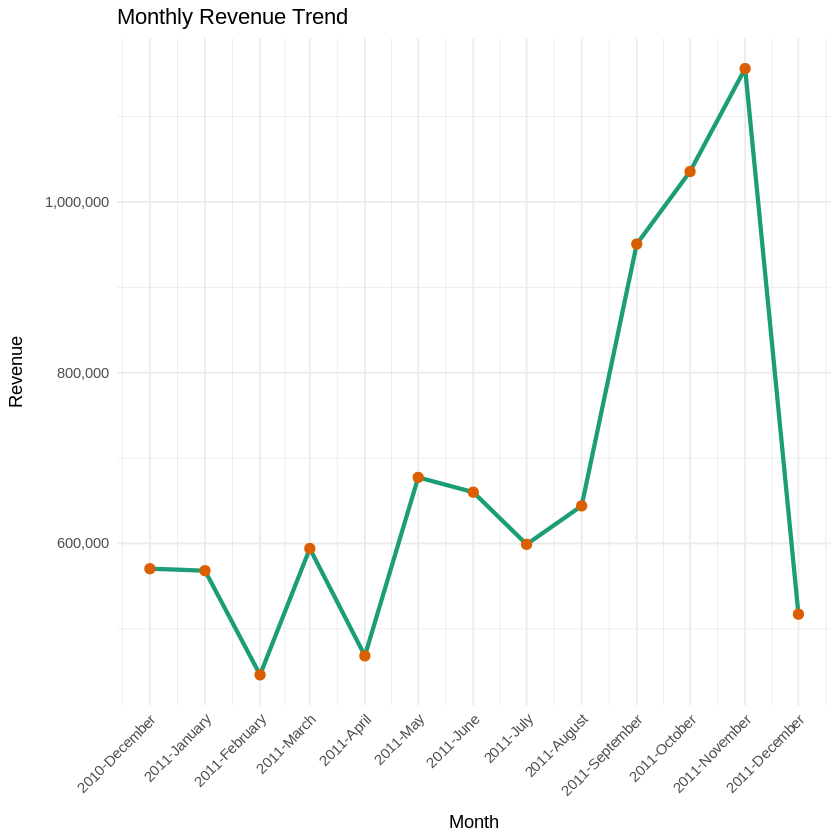

In [ ]:
ggplot(monthly_sales, aes(x = month_date, y = total_revenue, group = 1)) +
  geom_line(color = "#1b9e77", size = 1.2) +
  geom_point(color = "#d95f02", size = 2.5) +
  labs(title = "Monthly Revenue Trend",
       x = "Month",
       y = "Revenue") +
  scale_x_date(date_labels = "%Y-%B", date_breaks = "1 month") +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#####**Distribution of order values**

In [ ]:
order_values <- df_clean %>%
  group_by(InvoiceNo) %>%
  summarise(order_value = sum(Revenue, na.rm = TRUE))

head(order_values)

InvoiceNo,order_value
<chr>,<dbl>
536365,139.12
536366,22.20
536367,278.73
536368,70.05
536369,17.85
536370,855.86


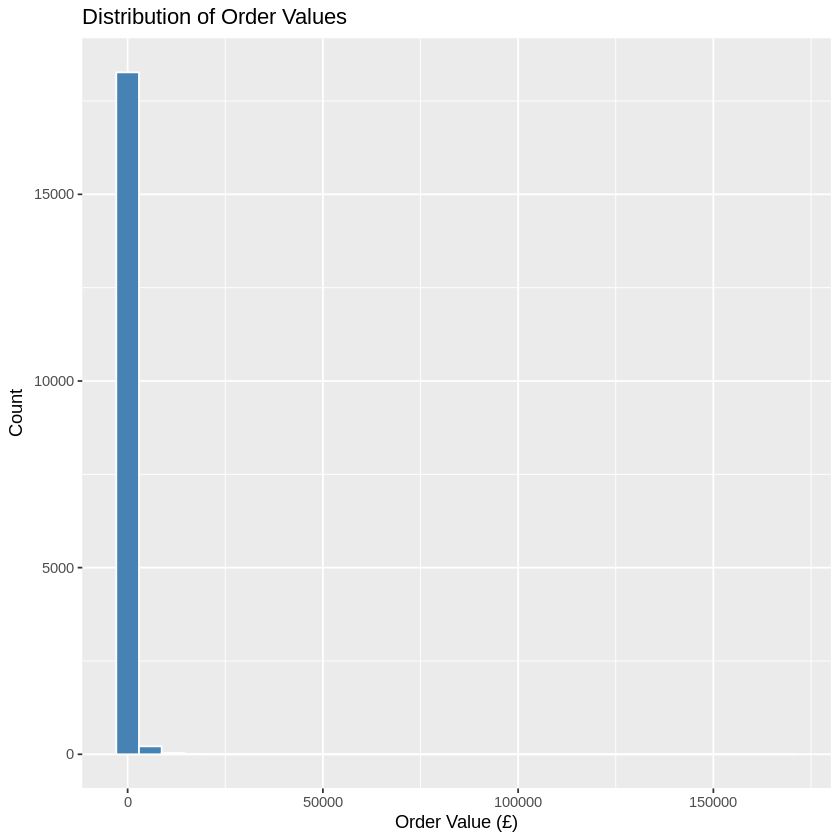

In [ ]:
ggplot(order_values, aes(x = order_value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Order Values",
       x = "Order Value (£)",
       y = "Count")

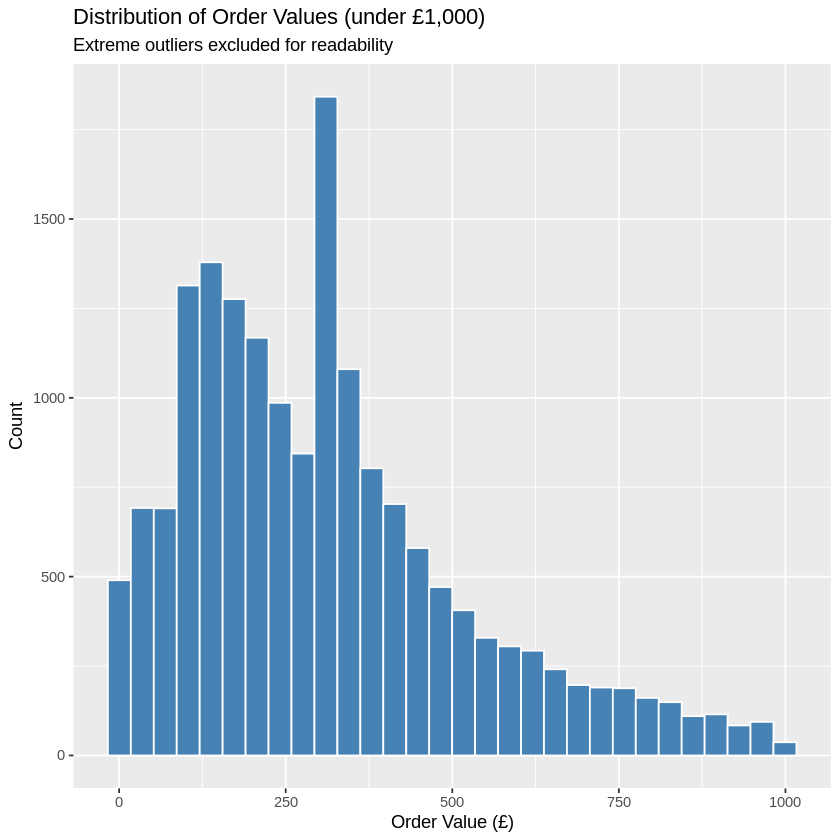

In [ ]:
ggplot(order_values %>% filter(order_value < 1000), aes(x = order_value)) +
  geom_histogram(bins = 30, fill = "steelblue", colour = "white") +
  labs(title = "Distribution of Order Values (under £1,000)",
       subtitle = "Extreme outliers excluded for readability",
       x = "Order Value (£)",
       y = "Count")

####**ABC Product Segmentation**


ABC product classification is based on the Pareto principle, or 80/20 rule, which states that 80% of sales typically come from 20% of the products. It categorizes the products into three classes - A, B, and C - according to the specific criteria or metric such as sales/revenue or profit. It assigns class A to all products where the cumulative percentage is up to 80%, class B to those where the cumulative percentage contribution is between 80% and 95%, and assigns C to the rest. The result of ABC analysis is the grouping of the products in accordance with their degree of influence on the company's success, in this case, profit. Managing the inventory on the most important 20% of products can lead to better efficiency and profits.

##### **Build ABC Classification Table**

In [ ]:
abc_table <- df_clean %>%
  group_by(Description) %>%
  summarise(product_revenue = sum(Revenue, na.rm = TRUE)) %>%
  arrange(desc(product_revenue)) %>%
  mutate(
    revenue_share = product_revenue / sum(product_revenue),
    cumulative_share = cumsum(revenue_share),
    abc_class = case_when(
      cumulative_share <= 0.80 ~ "A",
      cumulative_share <= 0.95 ~ "B",
      TRUE ~ "C"
    )
  )

head(abc_table, 20)

Description,product_revenue,revenue_share,cumulative_share,abc_class
<chr>,<dbl>,<dbl>,<dbl>,<chr>
"PAPER CRAFT , LITTLE BIRDIE",168469.60,0.018956413,0.01895641,A
REGENCY CAKESTAND 3 TIER,142264.75,0.016007810,0.03496422,A
WHITE HANGING HEART T-LIGHT HOLDER,100392.10,0.011296246,0.04626047,A
JUMBO BAG RED RETROSPOT,85040.54,0.009568869,0.05582934,A
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.009161114,0.06499045,A
POSTAGE,77803.96,0.008754600,0.07374505,A
PARTY BUNTING,68785.23,0.007739801,0.08148485,A
ASSORTED COLOUR BIRD ORNAMENT,56413.03,0.006347666,0.08783252,A
Manual,53419.93,0.006010878,0.09384340,A


##### **ABC Product Segments Analysis**

######**Count of Products by ABC Segment**

In [ ]:
abc_table %>%
  count(abc_class)

abc_class,n
<chr>,<int>
A,808
B,956
C,2102


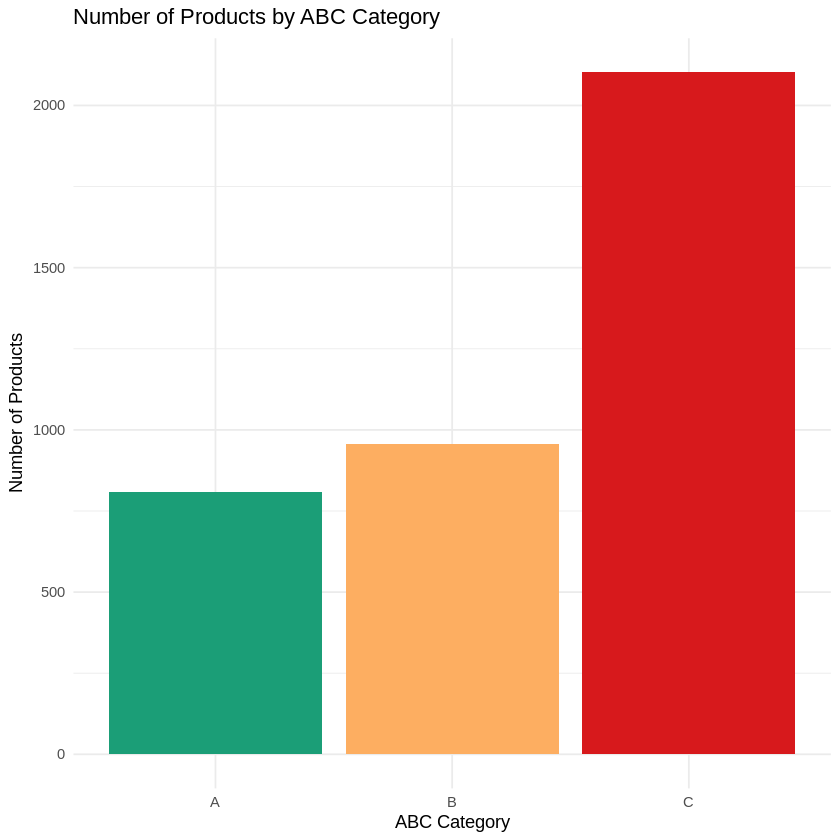

In [ ]:
ggplot(abc_table %>% count(abc_class),
       aes(x = abc_class, y = n, fill = abc_class)) +
  geom_col() +
  labs(title = "Number of Products by ABC Category",
       x = "ABC Category",
       y = "Number of Products") +
  scale_fill_manual(values = c(
    "A" = "#1b9e77",  # green
    "B" = "#fdae61",  # orange
    "C" = "#d7191c"   # red
  )) +
  theme_minimal() +
  theme(legend.position = "none")

######**Revenue Contribution by ABC Segment**

In [ ]:
abc_profitability <- abc_table %>%
  group_by(abc_class) %>%
  summarise(total_revenue = sum(product_revenue), .groups = "drop") %>%
  mutate(percentage = total_revenue / sum(total_revenue) * 100)

abc_profitability

abc_class,total_revenue,percentage
<chr>,<dbl>,<dbl>
A,7108960.8,79.990927
B,1333578.9,15.005599
C,444669.2,5.003474


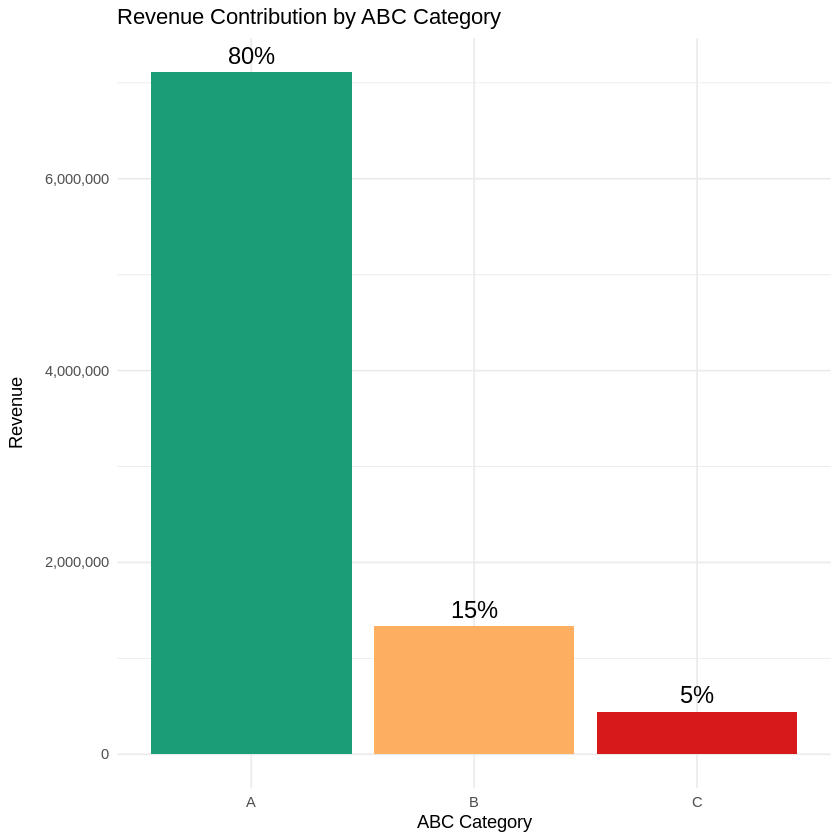

In [ ]:
ggplot(abc_profitability,
       aes(x = abc_class, y = total_revenue, fill = abc_class)) +
  geom_col() +
  geom_text(aes(label = paste0(round(percentage, 1), "%")),
            vjust = -0.5, size = 5) +
  labs(title = "Revenue Contribution by ABC Category",
       x = "ABC Category",
       y = "Revenue") +
  scale_fill_manual(values = c(
    "A" = "#1b9e77",
    "B" = "#fdae61",
    "C" = "#d7191c"
  )) +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal() +
  theme(legend.position = "none")

######**ABC Segment Performance Over Time**

In [ ]:
df_with_abc <- df_clean %>%
  left_join(abc_table %>% select(Description, abc_class), by = "Description")

In [ ]:
abc_summary <- abc_table %>%
  count(abc_class) %>%
  mutate(percentage = n / sum(n) * 100)

abc_summary

abc_class,n,percentage
<chr>,<int>,<dbl>
A,808,20.90016
B,956,24.72840
C,2102,54.37144


In [ ]:
abc_time <- df_with_abc %>%
  group_by(Year, MonthNum, abc_class) %>%
  summarise(total_revenue = sum(Revenue, na.rm = TRUE), .groups = "drop") %>%
  mutate(month_date = as.Date(paste(Year, MonthNum, "01", sep = "-"))) %>%
  arrange(month_date)

abc_time

Year,MonthNum,abc_class,total_revenue,month_date
<dbl>,<dbl>,<chr>,<dbl>,<date>
2010,12,A,432450.78,2010-12-01
2010,12,B,93243.93,2010-12-01
2010,12,C,44728.02,2010-12-01
2011,1,A,452599.87,2011-01-01
2011,1,B,81628.75,2011-01-01
2011,1,C,33872.69,2011-01-01
2011,2,A,346171.56,2011-02-01
2011,2,B,71764.22,2011-02-01
2011,2,C,28149.14,2011-02-01


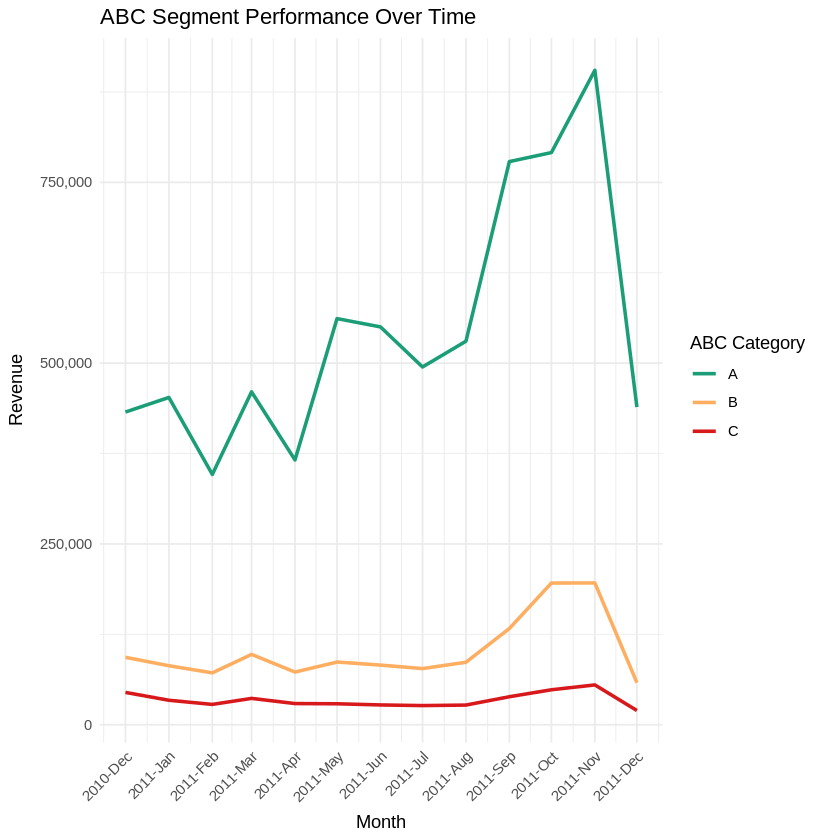

In [ ]:
ggplot(abc_time, aes(x = month_date, y = total_revenue, color = abc_class)) +
  geom_line(size = 1) +
  labs(title = "ABC Segment Performance Over Time",
       x = "Month",
       y = "Revenue",
       color = "ABC Category") +
  scale_color_manual(values = c(
    "A" = "#1b9e77",
    "B" = "#fdae61",
    "C" = "#d7191c"
  )) +
  scale_y_continuous(labels = scales::comma) +
  scale_x_date(date_labels = "%Y-%b", date_breaks = "1 month") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

####**Prepare Data For Machine Learning**

In [ ]:
ml_data <- df_clean %>%
  group_by(Description, StockCode, Year, MonthNum) %>%
  summarise(
    Quantity_Sold = sum(Quantity, na.rm = TRUE),
    Revenue       = sum(Revenue, na.rm = TRUE),
    Avg_Price     = mean(UnitPrice, na.rm = TRUE),
    Orders        = n_distinct(InvoiceNo),
    .groups = "drop"
  ) %>%
  left_join(
    abc_table %>% select(Description, abc_class),by = "Description") %>%
  mutate(
    abc_class = as.factor(abc_class)
  )

##### **Preview ML Dataset**

In [ ]:
head(ml_data)

Description,StockCode,Year,MonthNum,Quantity_Sold,Revenue,Avg_Price,Orders,abc_class
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>
10 COLOUR SPACEBOY PEN,22418,2010,12,547,464.95,0.8500000,25,A
10 COLOUR SPACEBOY PEN,22418,2011,1,276,234.60,0.8500000,13,A
10 COLOUR SPACEBOY PEN,22418,2011,2,216,183.60,0.8500000,9,A
10 COLOUR SPACEBOY PEN,22418,2011,3,408,346.80,0.8500000,21,A
10 COLOUR SPACEBOY PEN,22418,2011,4,216,183.60,0.8500000,10,A
10 COLOUR SPACEBOY PEN,22418,2011,5,636,521.88,0.8431579,19,A


#####**Create Lag Features**

In [ ]:
set.seed(42)

ml_data <- ml_data %>%
  arrange(Description, Year, MonthNum) %>%
  group_by(Description) %>%
  mutate(
    lag1_qty  = lag(Quantity_Sold, 1),
    lag2_qty  = lag(Quantity_Sold, 2),
    roll3_avg = rollmean(Quantity_Sold, k = 3, fill = NA, align = "right")
  ) %>%
  ungroup() %>%
  filter(
    !is.na(lag1_qty),
    !is.na(lag2_qty),
    !is.na(roll3_avg)
  )

##### **Check Row Counts After Filtering**

In [ ]:
cat("Rows available for modeling:", nrow(ml_data), "\n")
cat("Products remaining after filter:", n_distinct(ml_data$Description), "\n")
cat("Products dropped (too few months):",
    n_distinct(df_clean$Description) - n_distinct(ml_data$Description), "\n")

Rows available for modeling: 23337 
Products remaining after filter: 3282 
Products dropped (too few months): 584 


In [ ]:
# (ml_data preview already shown above)

##### **Log-Transform Target Variable**

In [ ]:
# Log-transform target variable to reduce skewness
ml_data <- ml_data %>%
  mutate(Log_Quantity = log1p(Quantity_Sold))

head(ml_data)

Description,StockCode,Year,MonthNum,Quantity_Sold,Revenue,Avg_Price,Orders,abc_class,lag1_qty,lag2_qty,roll3_avg,Log_Quantity
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
10 COLOUR SPACEBOY PEN,22418,2011,2,216,183.60,0.8500000,9,A,276,547,346.3333,5.379897
10 COLOUR SPACEBOY PEN,22418,2011,3,408,346.80,0.8500000,21,A,216,276,300.0000,6.013715
10 COLOUR SPACEBOY PEN,22418,2011,4,216,183.60,0.8500000,10,A,408,216,280.0000,5.379897
10 COLOUR SPACEBOY PEN,22418,2011,5,636,521.88,0.8431579,19,A,216,408,420.0000,6.456770
10 COLOUR SPACEBOY PEN,22418,2011,6,612,501.48,0.8413333,15,A,636,216,488.0000,6.418365
10 COLOUR SPACEBOY PEN,22418,2011,7,465,376.53,0.8413333,15,A,612,636,571.0000,6.144186


####**Split Training & Testing Data**

##### **Time-based split**

In [ ]:
# Time-based split (train on past, test on future)
train_data <- ml_data %>%
  filter(Year < 2011 | (Year == 2011 & MonthNum <= 9))

test_data <- ml_data %>%
  filter(Year == 2011 & MonthNum >= 10)

In [ ]:
cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows: ", nrow(test_data),  "\n")

Training rows: 16296 
Testing rows:  7041 


##### **Define feature columns**

In [ ]:
# 'Year' removed from features — it causes multicollinearity in Linear Regression
# MonthNum + lag features already capture the time signal
features <- c("MonthNum", "Avg_Price", "Orders", "abc_class",
              "lag1_qty", "lag2_qty", "roll3_avg")

x_train <- train_data %>% select(all_of(features))
y_train <- train_data$Log_Quantity

x_test  <- test_data %>% select(all_of(features))
y_test  <- test_data$Log_Quantity

# Ensure factor levels match between train and test (required for XGBoost)
x_test$abc_class <- factor(x_test$abc_class, levels = levels(x_train$abc_class))

####**Train Machine Learning Model**

#####**Random Forest**


Call:
 randomForest(x = x_train, y = y_train, ntree = 300, mtry = 3,      importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 300
No. of variables tried at each split: 3

          Mean of squared residuals: 0.125639
                    % Var explained: 95.66


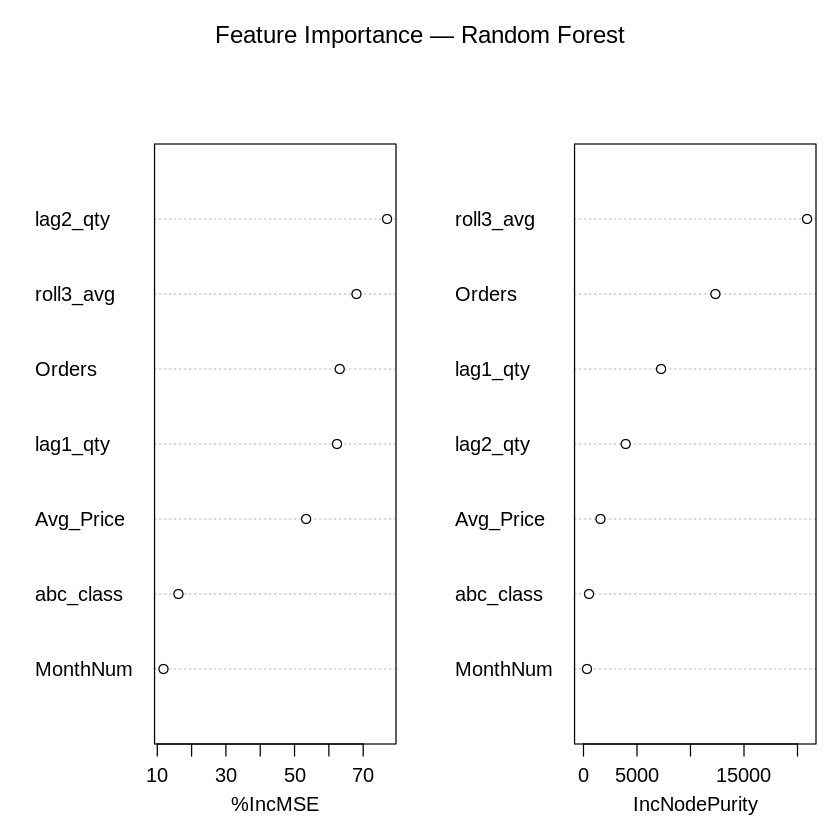

In [ ]:
set.seed(42)

rf_model <- randomForest(
  x          = x_train,
  y          = y_train,
  ntree      = 300,
  mtry       = 3,
  importance = TRUE
)

print(rf_model)
varImpPlot(rf_model, main = "Feature Importance — Random Forest")

#####**XGBOOST**

In [ ]:
# XGBoost needs a numeric matrix — encode abc_class as numeric first
x_train_xgb <- model.matrix(~ . - 1, data = x_train)
x_test_xgb  <- model.matrix(~ . - 1, data = x_test)

set.seed(42)

xgb_model <- xgboost(
  x             = x_train_xgb,
  y             = y_train,
  nrounds       = 200,
  max_depth     = 6,
  learning_rate = 0.1,
  objective     = "reg:squarederror"
)

###### **XGBoost Feature Importance**

      Feature         Gain        Cover   Frequency
       <char>        <num>        <num>       <num>
1:  roll3_avg 8.041469e-01 0.3762425936 0.252741559
2:     Orders 9.872298e-02 0.1052415670 0.120974009
3:   lag2_qty 3.977945e-02 0.2226311474 0.215093688
4:   lag1_qty 3.790945e-02 0.2093633105 0.227182454
5:  Avg_Price 1.784817e-02 0.0631330309 0.113807098
6:   MonthNum 1.160525e-03 0.0103919009 0.056558156
7: abc_classB 1.778087e-04 0.0001609906 0.005267248
8: abc_classC 1.621843e-04 0.0075273729 0.004317416
9: abc_classA 9.250686e-05 0.0053080863 0.004058371


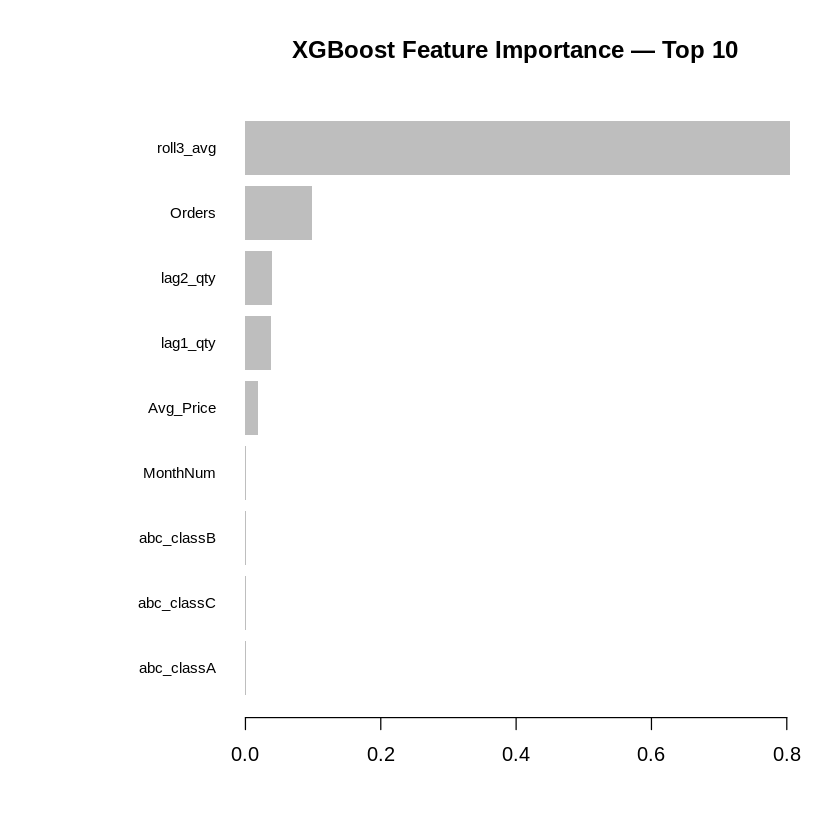

In [ ]:
# Feature importance for XGBoost
importance_matrix <- xgb.importance(
  model         = xgb_model,
  feature_names = colnames(x_train_xgb)
)

print(importance_matrix)
xgb.plot.importance(importance_matrix, top_n = 10,
                    main = "XGBoost Feature Importance — Top 10")

#####**Gradient Boosting**

In [ ]:
set.seed(42)

gbm_train <- cbind(x_train, Log_Quantity = y_train)

gbm_model <- gbm(
  Log_Quantity ~ .,
  data              = gbm_train,
  distribution      = "gaussian",
  n.trees           = 300,
  interaction.depth = 4,
  shrinkage         = 0.1,
  verbose           = FALSE
)

####**Model Predictions**

In [ ]:
# Predict on log scale
rf_preds_log    <- predict(rf_model,    newdata = x_test)
xgb_preds_log   <- predict(xgb_model,   newdata = x_test_xgb)
gbm_preds_log   <- predict(gbm_model,   newdata = x_test, n.trees = 300)

In [ ]:
# Convert back to original scale
rf_preds    <- expm1(rf_preds_log)
xgb_preds   <- expm1(xgb_preds_log)
gbm_preds   <- expm1(gbm_preds_log)

# Actual values
actual <- expm1(y_test)

In [ ]:
head(data.frame(
  Actual = actual,
  RF     = round(rf_preds),
  XGB    = round(xgb_preds),
  GBM    = round(gbm_preds)
))

,Actual,RF,XGB,GBM
,<dbl>,<dbl>,<dbl>,<dbl>
1,825,767,786,665
2,783,743,732,751
3,99,201,173,162
4,142,151,152,174
5,327,307,373,309
6,43,70,70,64


####**Evaluate Model**

In [ ]:
rf_rmse  <- rmse(actual, rf_preds)
xgb_rmse <- rmse(actual, xgb_preds)
gbm_rmse <- rmse(actual, gbm_preds)

rf_mae   <- mae(actual, rf_preds)
xgb_mae  <- mae(actual, xgb_preds)
gbm_mae  <- mae(actual, gbm_preds)

# Proper R² formula (robust even if predictions have near-zero variance)
r2_score <- function(actual, predicted) {
  ss_res <- sum((actual - predicted)^2)
  ss_tot <- sum((actual - mean(actual))^2)
  return(1 - ss_res / ss_tot)
}

rf_r2  <- r2_score(actual, rf_preds)
xgb_r2 <- r2_score(actual, xgb_preds)
gbm_r2 <- r2_score(actual, gbm_preds)

model_results <- data.frame(
  Model     = c("Random Forest", "XGBoost", "GBM"),
  RMSE      = round(c(rf_rmse,  xgb_rmse,  gbm_rmse), 2),
  MAE       = round(c(rf_mae,   xgb_mae,   gbm_mae),  2),
  R_Squared = round(c(rf_r2,    xgb_r2,    gbm_r2),   4)
)

print(model_results)

          Model   RMSE   MAE R_Squared
1 Random Forest 213.97 47.66    0.7738
2       XGBoost 194.43 35.15    0.8132
3           GBM 216.64 52.37    0.7681


##### **Select Best Model**

In [ ]:
# Automatically select best model based on R²
best_model_name <- model_results$Model[which.max(model_results$R_Squared)]
cat("Best model:", best_model_name, "\n")

best_predictions <- switch(best_model_name,
  "Random Forest" = rf_preds,
  "XGBoost"       = xgb_preds,
  "GBM"           = gbm_preds
)

Best model: XGBoost 


##### **Build Predictions Table**

In [ ]:
test_results <- test_data %>%
  mutate(
    Actual_Quantity = actual,
    RF_Predicted    = round(rf_preds),
    XGB_Predicted   = round(xgb_preds),
    GBM_Predicted   = round(gbm_preds),
    Best_Predicted  = round(best_predictions)
  )

head(test_results, 20)

Description,StockCode,Year,MonthNum,Quantity_Sold,Revenue,Avg_Price,Orders,abc_class,lag1_qty,lag2_qty,roll3_avg,Log_Quantity,Actual_Quantity,RF_Predicted,XGB_Predicted,GBM_Predicted,Best_Predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10 COLOUR SPACEBOY PEN,22418,2011,10,825,689.55,0.9379412,34,A,571,613,669.666667,6.716595,825,767,786,665,786
10 COLOUR SPACEBOY PEN,22418,2011,11,783,667.89,0.8722857,35,A,825,571,726.333333,6.664409,783,743,732,751,732
10 COLOUR SPACEBOY PEN,22418,2011,12,99,86.49,0.9800000,6,A,783,825,569.000000,4.605170,99,201,173,162,173
12 COLOURED PARTY BALLOONS,22436,2011,10,142,92.30,0.6500000,12,B,170,152,154.666667,4.962845,142,151,152,174,152
12 COLOURED PARTY BALLOONS,22436,2011,11,327,213.75,0.7021739,22,B,142,170,213.000000,5.793014,327,307,373,309,373
12 COLOURED PARTY BALLOONS,22436,2011,12,43,27.95,0.6500000,4,B,327,142,170.666667,3.784190,43,70,70,64,70
12 DAISY PEGS IN WOOD BOX,21448,2011,10,5,8.25,1.6500000,3,C,6,14,8.333333,1.791759,5,6,7,7,7
12 EGG HOUSE PAINTED WOOD,22282,2011,10,15,215.67,14.2762500,8,B,8,4,9.000000,2.772589,15,13,15,15,15
12 EGG HOUSE PAINTED WOOD,22282,2011,11,19,227.85,12.4928571,7,B,15,8,14.000000,2.995732,19,16,18,16,18


##### **Actual vs Predicted — All Models Plot**

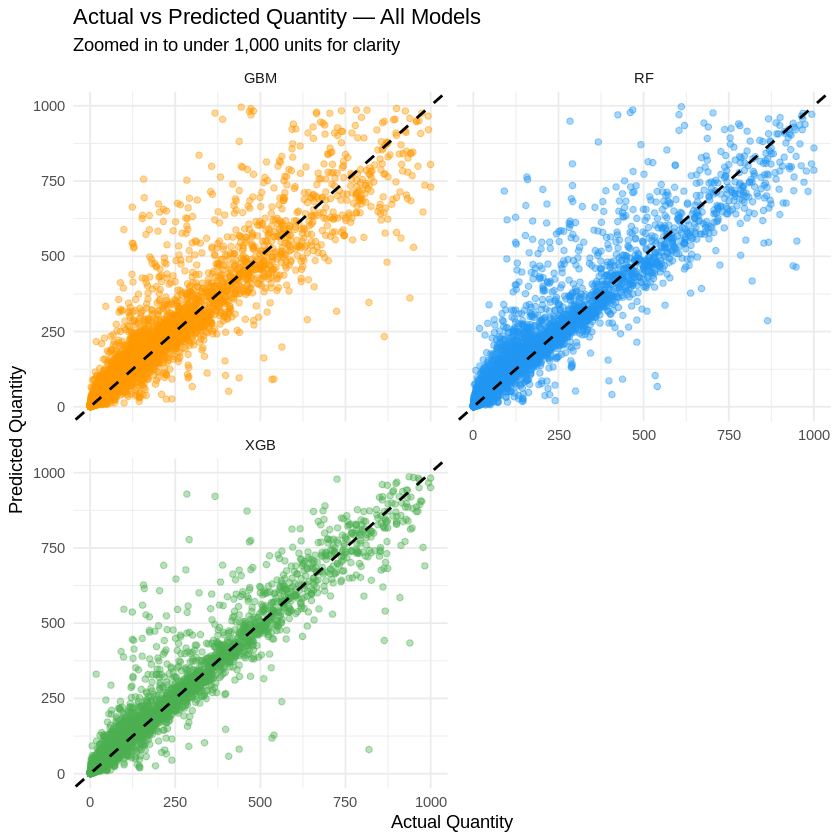

In [ ]:
comparison_df <- data.frame(
  Actual = actual,
  RF     = rf_preds,
  XGB    = xgb_preds,
  GBM    = gbm_preds
) %>%
  tidyr::pivot_longer(cols = -Actual, names_to = "Model", values_to = "Predicted") %>%
  filter(Actual < 1000, Predicted < 1000)

ggplot(comparison_df, aes(x = Actual, y = Predicted, colour = Model)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_abline(slope = 1, intercept = 0, colour = "black", linewidth = 0.8, linetype = "dashed") +
  facet_wrap(~ Model, nrow = 2) +
  scale_colour_manual(values = c(
    RF  = "#2196F3",
    XGB = "#4CAF50",
    GBM = "#FF9800"
  )) +
  labs(title = "Actual vs Predicted Quantity — All Models",
       subtitle = "Zoomed in to under 1,000 units for clarity",
       x = "Actual Quantity", y = "Predicted Quantity") +
  theme_minimal() +
  theme(legend.position = "none")

#### **Supervised time-based forecasting**

In [ ]:
# Use November 2011 as the base for forecasting December 2011
forecast_data <- ml_data %>%
  filter(Year == 2011, MonthNum == 11)

# Update the forecast month to December 2011
forecast_data <- forecast_data %>%
  mutate(
    Year     = 2011,
    MonthNum = 12
  )

# Align abc_class factor levels with training data
forecast_data$abc_class <- factor(forecast_data$abc_class, levels = levels(x_train$abc_class))

# Select best model for forecasting
best_model <- switch(best_model_name,
  "Random Forest" = rf_model,
  "XGBoost"       = xgb_model,
  "GBM"           = gbm_model
)

##### **Predict December 2011 Demand**

In [ ]:
# Prepare forecast matrix (needed for XGBoost)
forecast_matrix <- model.matrix(~ . - 1, data = forecast_data %>% select(all_of(features)))

In [ ]:
# Predict using best model
forecast_log <- if (best_model_name == "XGBoost") {
  predict(best_model, newdata = forecast_matrix)
} else if (best_model_name == "GBM") {
  predict(best_model, newdata = forecast_data, n.trees = 300)
} else {
  predict(best_model, newdata = forecast_data)
}

forecast_qty <- expm1(forecast_log)

In [ ]:
# Build forecast table
monthly_forecast <- forecast_data %>%
  select(Description, StockCode, abc_class, Year, MonthNum) %>%
  mutate(Forecasted_Quantity = round(forecast_qty)) %>%
  arrange(desc(Forecasted_Quantity))

cat("Best model used:", best_model_name, "\n")
cat("Forecast complete —", nrow(monthly_forecast),
    "products forecasted for December 2011\n")
head(monthly_forecast, 20)

Best model used: XGBoost 
Forecast complete — 2516 products forecasted for December 2011


Description,StockCode,abc_class,Year,MonthNum,Forecasted_Quantity
<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
DISCO BALL CHRISTMAS DECORATION,20668,B,2011,12,3898
ASSORTED COLOUR BIRD ORNAMENT,84879,A,2011,12,3831
WOODEN HEART CHRISTMAS SCANDINAVIAN,22577,A,2011,12,3741
POPCORN HOLDER,22197,A,2011,12,3596
WOODEN STAR CHRISTMAS SCANDINAVIAN,22578,A,2011,12,3594
WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,A,2011,12,3415
JUMBO BAG VINTAGE DOILY,23203,A,2011,12,3346
JUMBO BAG 50'S CHRISTMAS,23344,A,2011,12,3084
JUMBO BAG RED RETROSPOT,85099B,A,2011,12,3069


####**Generate business Insights**

In [ ]:
# Build business insight dataset
q80 <- quantile(monthly_forecast$Forecasted_Quantity, 0.80, na.rm = TRUE)
q50 <- quantile(monthly_forecast$Forecasted_Quantity, 0.50, na.rm = TRUE)

insight_data <- monthly_forecast %>%
  left_join(
    df_clean %>%
      group_by(Description) %>%
      summarise(
        total_revenue = sum(Revenue, na.rm = TRUE),
        active_months = n_distinct(paste(year(InvoiceDate), month(InvoiceDate))),
        .groups = "drop"
      ),
    by = "Description"
  ) %>%
  mutate(
    demand_level = case_when(
      Forecasted_Quantity >= q80 ~ "High",
      Forecasted_Quantity >= q50 ~ "Medium",
      TRUE ~ "Low"
    ),
    recommendation = case_when(
      abc_class == "A" & demand_level == "High"   ~ "Expand Stock",
      abc_class == "A" & demand_level == "Medium" ~ "Optimize Stock",
      abc_class == "A" & demand_level == "Low"    ~ "Investigate Demand Drop",
      abc_class == "B" & demand_level == "High"   ~ "Increase Monitoring",
      abc_class == "B"                            ~ "Maintain Stock",
      abc_class == "C" & demand_level == "Low"    ~ "Consider Discontinuation",
      TRUE                                        ~ "Reduce Assortment"
    )
  )

head(insight_data)

Description,StockCode,abc_class,Year,MonthNum,Forecasted_Quantity,total_revenue,active_months,demand_level,recommendation
<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
DISCO BALL CHRISTMAS DECORATION,20668,B,2011,12,3898,1397.04,13,High,Increase Monitoring
ASSORTED COLOUR BIRD ORNAMENT,84879,A,2011,12,3831,56413.03,13,High,Expand Stock
WOODEN HEART CHRISTMAS SCANDINAVIAN,22577,A,2011,12,3741,3415.90,13,High,Expand Stock
POPCORN HOLDER,22197,A,2011,12,3596,23417.51,7,High,Expand Stock
WOODEN STAR CHRISTMAS SCANDINAVIAN,22578,A,2011,12,3594,3164.08,7,High,Expand Stock
WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,A,2011,12,3415,13558.41,13,High,Expand Stock


#####**INSIGHT 1: What does our product portfolio look like?**

In [ ]:
cat("Out of", nrow(insight_data), "products analyzed:\n\n")

rec_summary <- insight_data %>%
  count(recommendation) %>%
  arrange(desc(n))

for (i in 1:nrow(rec_summary)) {
  cat("→", rec_summary$n[i], "products —", rec_summary$recommendation[i], "\n")
}

cat("\nClass-A products (top 80% revenue):", sum(insight_data$abc_class == "A"), "\n")
cat("Class-B products:                  ", sum(insight_data$abc_class == "B"), "\n")
cat("Class-C products:                  ", sum(insight_data$abc_class == "C"), "\n")
cat("\n→ Most products fall into:", rec_summary$recommendation[1], "\n")

Out of 2516 products analyzed:

→ 780 products — Consider Discontinuation 
→ 671 products — Maintain Stock 
→ 342 products — Expand Stock 
→ 268 products — Optimize Stock 
→ 190 products — Reduce Assortment 
→ 145 products — Increase Monitoring 
→ 120 products — Investigate Demand Drop 

Class-A products (top 80% revenue): 730 
Class-B products:                   816 
Class-C products:                   970 

→ Most products fall into: Consider Discontinuation 


#####**INSIGHT 2: Which products should we stock up on?**

In [ ]:
top_stock <- insight_data %>%
  filter(recommendation == "Expand Stock") %>%
  arrange(desc(Forecasted_Quantity)) %>%
  slice_head(n = 10)

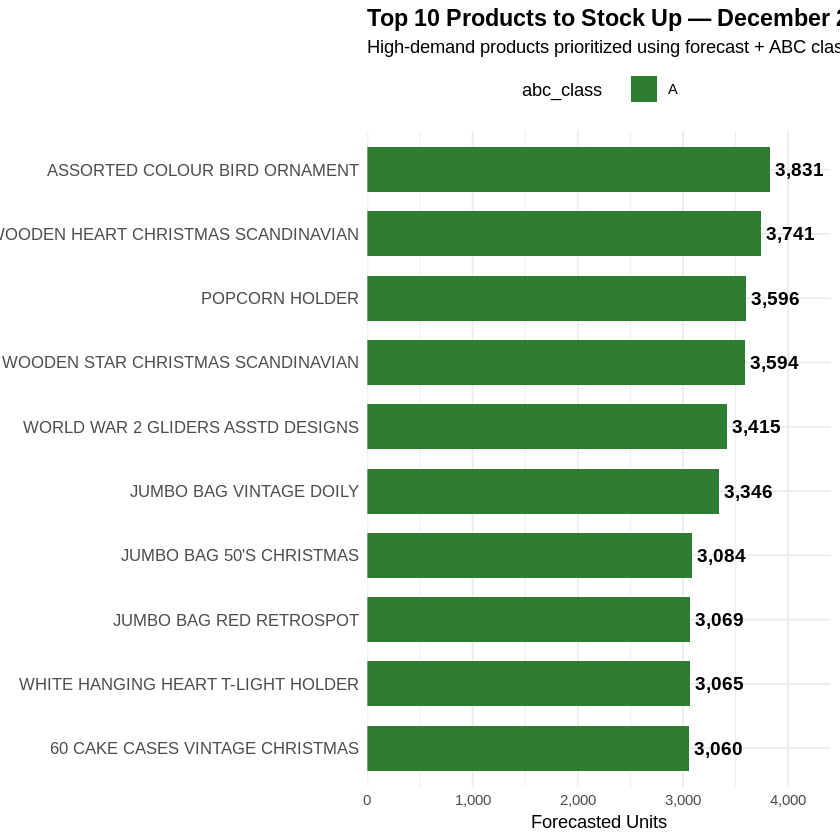

In [ ]:
ggplot(top_stock, aes(x = reorder(Description, Forecasted_Quantity),
                      y = Forecasted_Quantity,
                      fill = abc_class)) +

  geom_col(width = 0.7) +

  geom_text(aes(label = scales::comma(Forecasted_Quantity)),
            hjust = -0.1,
            size = 4,
            fontface = "bold") +

  coord_flip() +

  labs(title = "Top 10 Products to Stock Up — December 2011",
       subtitle = "High-demand products prioritized using forecast + ABC classification",
       x = NULL,
       y = "Forecasted Units") +

  scale_fill_manual(values = c(
    "A" = "#2E7D32",
    "B" = "#F9A825",
    "C" = "#C62828"
  )) +

  scale_y_continuous(labels = scales::comma,
                     expand = expansion(mult = c(0, 0.15))) +

  theme_minimal() +

  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 11),
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(size = 9),
    legend.position = "top"
  )

#####**INSIGHT 3: Which products are wasting shelf space?**

In [ ]:
cut_products <- insight_data %>%
  filter(recommendation == "Consider Discontinuation") %>%
  arrange(Forecasted_Quantity, total_revenue) %>%
  slice_head(n = 10) %>%
  select(Description, Forecasted_Quantity, total_revenue)

print(cut_products)

cat("\n→ These products show weak forecasted demand and may not justify shelf space.\n")

# A tibble: 10 × 3
   Description                         Forecasted_Quantity total_revenue
   <chr>                                             <dbl>         <dbl>
 1 TURQUOISE CHRISTMAS TREE                              1          6.25
 2 DIAMANTE HAIR GRIP PACK/2 MONTANA                     1         13.2 
 3 SILVER/AMETHYST DROP EARRINGS LEAF                    1         14.8 
 4 DIAMANTE HAIR GRIP PACK/2 BLACK DIA                   1         14.8 
 5 DIAMANTE HAIR GRIP PACK/2 LT ROSE                     1         14.8 
 6 SILVER BLACK ORBIT BRACELET                           1         19.8 
 7 CLEAR CRYSTAL STAR PHONE CHARM                        1         20.4 
 8 FLORAL BLUE MONSTER                                   1         21.2 
 9 PINK PARTY SUNGLASSES                                 1         23.4 
10 PINK GREEN EMBROIDERY COSMETIC BAG                    1         23.6 

→ These products show weak forecasted demand and may not justify shelf space.


#####**INSIGHT 4: When does demand peak?**

In [ ]:
month_names <- c("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")

In [ ]:
seasonal <- df_clean %>%
  left_join(abc_table %>% select(Description, abc_class), by = "Description") %>%
  filter(abc_class == "A") %>%
  group_by(MonthNum) %>%
  summarise(total_qty = sum(Quantity, na.rm = TRUE), .groups = "drop")

peak_month <- seasonal %>%
  filter(total_qty == max(total_qty)) %>%
  pull(MonthNum)

cat("Peak demand month for Class-A products:", month_names[peak_month], "\n")
cat("→ Inventory planning should increase 4–6 weeks before peak demand.\n")

Peak demand month for Class-A products: Nov 
→ Inventory planning should increase 4–6 weeks before peak demand.


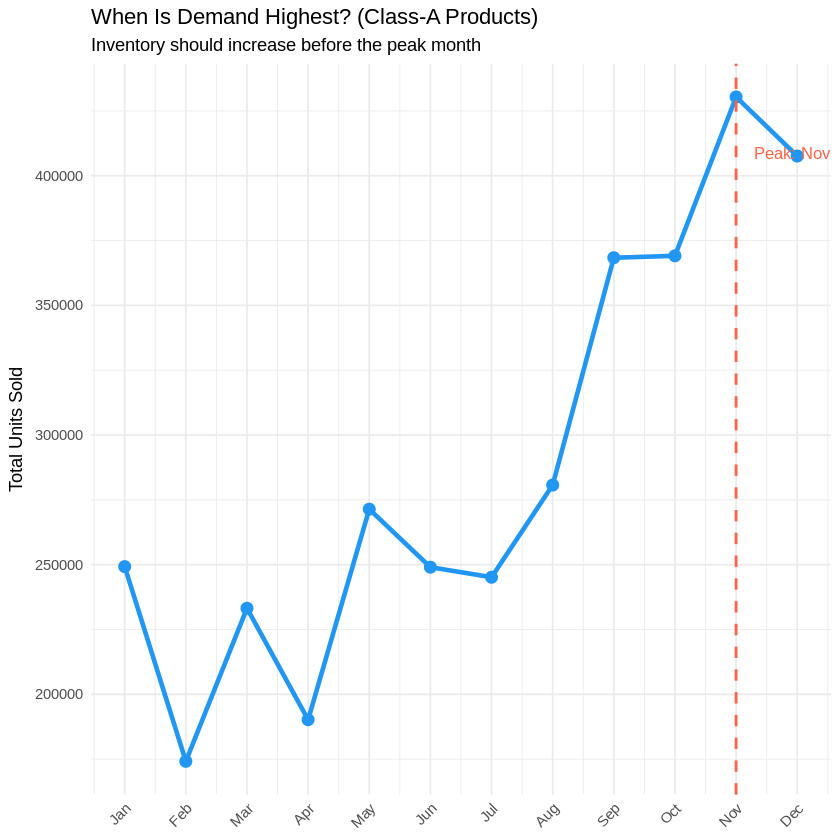

In [ ]:
ggplot(seasonal, aes(x = MonthNum, y = total_qty)) +
  geom_line(colour = "#2196F3", linewidth = 1.3) +
  geom_point(colour = "#2196F3", size = 3) +
  geom_vline(xintercept = peak_month, linetype = "dashed",
             colour = "tomato", linewidth = 0.8) +
  annotate("text",
           x = peak_month + 0.3,
           y = max(seasonal$total_qty) * 0.95,
           label = paste("Peak:", month_names[peak_month]),
           colour = "tomato",
           size = 3.5,
           hjust = 0) +
  scale_x_continuous(breaks = 1:12, labels = month_names) +
  labs(title = "When Is Demand Highest? (Class-A Products)",
       subtitle = "Inventory should increase before the peak month",
       x = NULL,
       y = "Total Units Sold") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

###### **Prepare Time-of-Day Data**

In [ ]:
df_time <- df_clean %>%
  mutate(
    Hour = hour(InvoiceDate),
    TimeOfDay = case_when(
      Hour >= 6  & Hour < 12 ~ "Morning",
      Hour >= 12 & Hour < 18 ~ "Afternoon",
      Hour >= 18 & Hour < 24 ~ "Evening",
      TRUE                   ~ "Night"
    )
  ) %>%
  left_join(abc_table %>% select(Description, abc_class), by = "Description") %>%
  filter(abc_class == "A")

###### **Sales by Day of Week**

In [ ]:
weekday_sales <- df_time %>%
  group_by(Weekday) %>%
  summarise(total_qty = sum(Quantity, na.rm = TRUE), .groups = "drop")

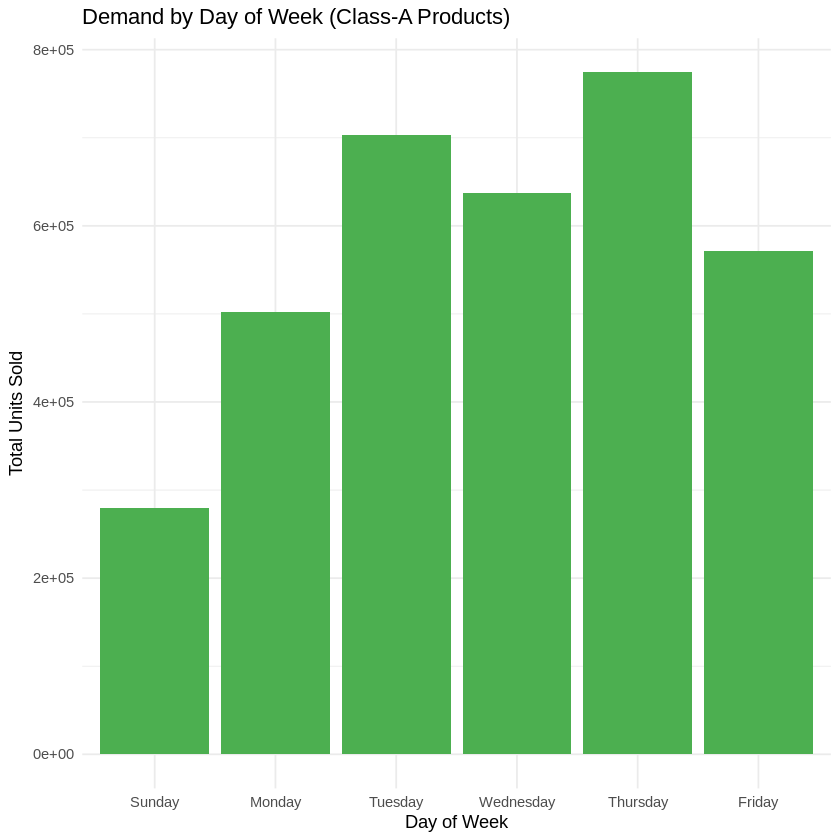

In [ ]:
ggplot(weekday_sales, aes(x = Weekday, y = total_qty)) +
  geom_col(fill = "#4CAF50") +
  labs(title = "Demand by Day of Week (Class-A Products)",
       x = "Day of Week",
       y = "Total Units Sold") +
  theme_minimal()

###### **Sales by Time of Day**

In [ ]:
time_sales <- df_time %>%
  group_by(TimeOfDay) %>%
  summarise(total_qty = sum(Quantity, na.rm = TRUE), .groups = "drop")

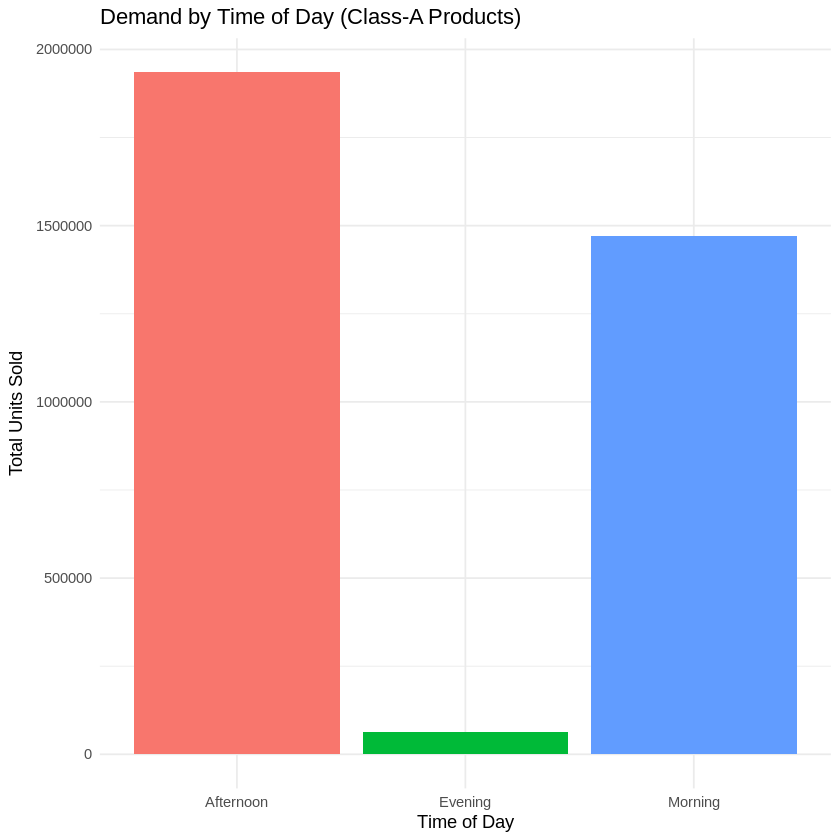

In [ ]:
ggplot(time_sales, aes(x = TimeOfDay, y = total_qty, fill = TimeOfDay)) +
  geom_col() +
  labs(title = "Demand by Time of Day (Class-A Products)",
       x = "Time of Day",
       y = "Total Units Sold") +
  theme_minimal() +
  theme(legend.position = "none")

###### **Demand Heatmap: Day × Time**

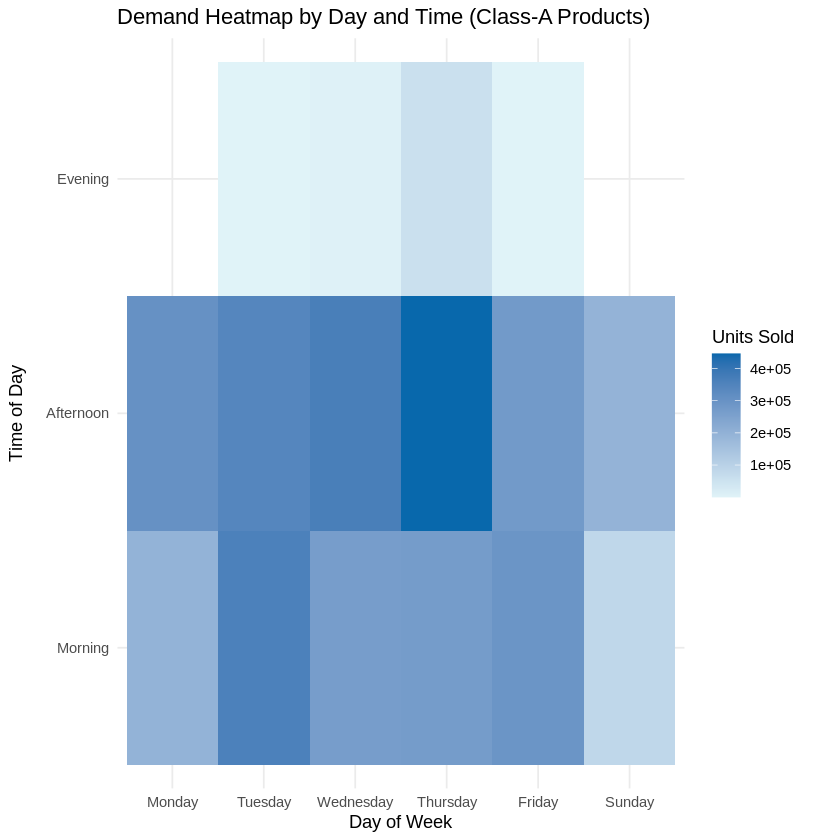

In [ ]:
heatmap_data <- df_time %>%
  mutate(
    Weekday = factor(
      Weekday,
      levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")
    ),
    TimeOfDay = factor(
      TimeOfDay,
      levels = c("Morning", "Afternoon", "Evening", "Night")
    )
  ) %>%
  group_by(Weekday, TimeOfDay) %>%
  summarise(total_qty = sum(Quantity, na.rm = TRUE), .groups = "drop")

ggplot(heatmap_data, aes(x = Weekday, y = TimeOfDay, fill = total_qty)) +
  geom_tile() +
  scale_fill_gradient(low = "#e0f3f8", high = "#0868ac") +
  labs(title = "Demand Heatmap by Day and Time (Class-A Products)",
       x = "Day of Week",
       y = "Time of Day",
       fill = "Units Sold") +
  theme_minimal()

#####**INSIGHT 5: What action should we take for each product?**

In [ ]:
final_plan <- insight_data %>%
  arrange(abc_class, desc(Forecasted_Quantity)) %>%
  select(
    Product        = Description,
    Class          = abc_class,
    `Forecast Qty` = Forecasted_Quantity,
    `Revenue (£)`  = total_revenue,
    Action         = recommendation
  )

head(final_plan, 15)

Product,Class,Forecast Qty,Revenue (£),Action
<chr>,<fct>,<dbl>,<dbl>,<chr>
ASSORTED COLOUR BIRD ORNAMENT,A,3831,56413.03,Expand Stock
WOODEN HEART CHRISTMAS SCANDINAVIAN,A,3741,3415.90,Expand Stock
POPCORN HOLDER,A,3596,23417.51,Expand Stock
WOODEN STAR CHRISTMAS SCANDINAVIAN,A,3594,3164.08,Expand Stock
WORLD WAR 2 GLIDERS ASSTD DESIGNS,A,3415,13558.41,Expand Stock
JUMBO BAG VINTAGE DOILY,A,3346,20641.40,Expand Stock
JUMBO BAG 50'S CHRISTMAS,A,3084,17636.04,Expand Stock
JUMBO BAG RED RETROSPOT,A,3069,85040.54,Expand Stock
WHITE HANGING HEART T-LIGHT HOLDER,A,3065,100392.10,Expand Stock


####**Export Data From Dashboard**

In [ ]:
dir.create("exports", showWarnings = FALSE)


In [ ]:
write.csv(df_clean, "exports/01_cleaned_data.csv", row.names = FALSE)


In [ ]:
write.csv(abc_table, "exports/02_abc_classification.csv", row.names = FALSE)


In [ ]:
write.csv(model_results, "exports/03_model_evaluation.csv", row.names = FALSE)


In [ ]:
write.csv(final_plan, "exports/04_assortment_plan_dec2011.csv", row.names = FALSE)


In [ ]:
write.csv(ml_data, "exports/05_ml_dataset.csv", row.names = FALSE)

In [ ]:
write.csv(test_results, "exports/06_predictions_vs_actual.csv", row.names = FALSE)

####**Build Dashboard**

??????

##**Final Analysis & Conclusion**

??????